In [4]:
# Cell 1: Run this first to install packages
!pip install tensorflow tensorflow_hub scikit-learn librosa numpy matplotlib

In [7]:
import os
import numpy as np
import tensorflow as tf
import tensorflow_hub as hub
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import librosa
import matplotlib.pyplot as plt


In [ ]:

# ===== CONFIGURATION =====
# PATH to your main folder containing sub-folders for each class
data_dir = "C:/Projects/MachineLearning/Sound/BabyCry/audio"

# List your classes (sub-folder names). The order matters for the final prediction.
classes = ['belly_pain', 'burping', 'cold_hot', 'discomfort', 'hungry', 'laugh', 'noise', 'silence', 'tired']
# =========================


In [12]:

# Load the pre-trained YAMNet model from TensorFlow Hub
yamnet_model = hub.load('https://tfhub.dev/google/yamnet/1')

# Function to load and preprocess a WAV file to the format YAMNet expects
def load_wav_for_yamnet(file_path, target_sr=16000):
    # Load audio file, force resampling to 16kHz (YAMNet's requirement)
    audio, original_sr = librosa.load(file_path, sr=target_sr, mono=True)
    # Ensure the audio is in the range [-1.0, +1.0] as required by YAMNet
    audio = audio / np.max(np.abs(audio)) if np.max(np.abs(audio)) > 0 else audio
    # YAMNet expects a specific length, but handles variable length by averaging embeddings.
    # We can use the full length of the audio.
    return audio


In [16]:

# Function to get the YAMNet embedding for an audio array
def get_yamnet_embedding(audio_data):
    # Run YAMNet on the audio data. This returns scores, embeddings, and the spectrogram.
    # We are only interested in the embeddings.
    _, embeddings, _ = yamnet_model(audio_data)
    # The model processes the audio in frames. We take the mean of all frame embeddings
    # to get a single, summary feature vector for the entire audio clip.
    return np.mean(embeddings.numpy(), axis=0)

# Main data preparation loop
print("[INFO] Loading audio files and extracting features...")
features = []  # List to hold our YAMNet feature vectors
labels = []    # List to hold our corresponding labels (e.g., 'hungry', 'tired')


[INFO] Loading audio files and extracting features...


In [17]:

# Loop through each class folder
for label_name in classes:
    class_dir = os.path.join(data_dir, label_name)
    if not os.path.isdir(class_dir):
        print(f"Warning: Directory {class_dir} not found. Skipping.")
        continue

    # Loop through each audio file in the class folder
    for audio_file in os.listdir(class_dir):
        if audio_file.endswith('.wav'):
            file_path = os.path.join(class_dir, audio_file)
            try:
                # 1. Load the audio
                audio = load_wav_for_yamnet(file_path)
                # 2. Get its YAMNet embedding (feature vector)
                embedding = get_yamnet_embedding(audio)
                # 3. Store the feature and its label
                features.append(embedding)
                labels.append(label_name)
            except Exception as e:
                print(f"Error processing {file_path}: {e}")


In [18]:

# Convert lists to NumPy arrays
X = np.array(features)
y = np.array(labels)

# Check if we have data
if len(X) == 0:
    raise ValueError("No audio files were found. Please check your data_dir path and file extensions.")

# Encode the text labels into integers (e.g., 'hungry' -> 0, 'tired' -> 1)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

# Optional but often helpful: Scale the features to have zero mean and unit variance.
# This helps the classifier converge faster and perform better.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [19]:

# ===== BUILD AND TRAIN THE CLASSIFIER =====
# We'll use a simple Neural Network classifier
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train.shape[1],)), # Input shape is the size of YAMNet embedding (1024)
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.5), # Helps prevent overfitting
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(len(classes), activation='softmax') # Output layer for our classes
])

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Let's see the model structure
model.summary()

# Train the model
print("[INFO] Training classifier on YAMNet features...")
history = model.fit(X_train_scaled, y_train,
                    epochs=50, # You can adjust this
                    batch_size=32,
                    validation_data=(X_test_scaled, y_test),
                    verbose=1)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 256)                 │         262,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 9)                   │           1,161 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 296,457 (1.13 MB)

 Trainable params: 296,457 (1.13 MB)

 Non-trainable params: 0 (0.00 B)

[INFO] Training classifier on YAMNet features...
Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.3218 - loss: 2.0646 - val_accuracy: 0.5083 - val_loss: 1.8779
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.4608 - loss: 1.9181 - val_accuracy: 0.5042 - val_loss: 1.6316
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5016 - loss: 1.5483 - val_accuracy: 0.4875 - val_loss: 1.7470
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5016 - loss: 1.8992 - val_accuracy: 0.4833 - val_loss: 1.8312
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.5204 - loss: 1.9112 - val_accuracy: 0.4708 - val_loss: 1.7553
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5131 - loss: 1.5870 - val_accuracy: 0.4667 - val_loss: 1.6775
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5444 - loss: 1.4689 - val_accuracy: 0.4625 - val_loss: 1.7569
Epoch 8/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy:


[INFO] Evaluating the model...
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


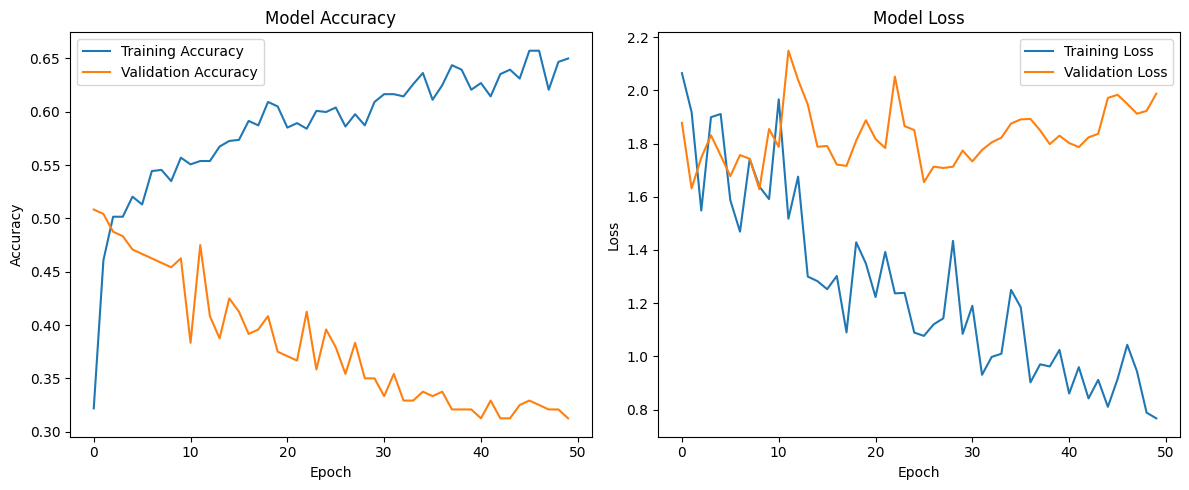

In [21]:

# ===== EVALUATE THE MODEL =====
print("\n[INFO] Evaluating the model...")
# Get predictions for the test set
y_pred = np.argmax(model.predict(X_test_scaled), axis=1)

# Convert numeric predictions back to original class names
y_pred_labels = label_encoder.inverse_transform(y_pred)
y_true_labels = label_encoder.inverse_transform(y_test)

# Print a detailed classification report
# print("\n" + classification_report(y_true_labels, y_pred_labels, target_names=classes))

# Plot training history to check for overfitting
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

# Function to predict a new, unseen audio file
def predict_cry_type(file_path):
    audio = load_wav_for_yamnet(file_path)
    embedding = get_yamnet_embedding(audio)
    embedding_scaled = scaler.transform(embedding.reshape(1, -1)) # Scale it
    prediction = model.predict(embedding_scaled, verbose=0)
    predicted_class_index = np.argmax(prediction, axis=1)
    predicted_class = label_encoder.inverse_transform(predicted_class_index)[0]
    confidence = np.max(prediction)
    print(f"Predicted cry type: {predicted_class} (Confidence: {confidence:.2f})")
    return predicted_class, confidence

# Example usage of the prediction function:
# predict_cry_type("path/to/a/new/test_audio.wav")

In [22]:
predict_cry_type("C:/Users/samma/Downloads/angry-baby-cry-36152.mp3")

Predicted cry type: tired (Confidence: 0.57)


(np.str_('tired'), np.float32(0.56885505))

In [29]:
predict_cry_type("C:/Users/samma/Downloads/laughing_baby.mp3")

Predicted cry type: laugh (Confidence: 0.98)


(np.str_('laugh'), np.float32(0.9829882))